# Display Test Accuracy

In [6]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat

from matplotlib import pyplot as plt
from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

In [5]:
%matplotlib widget

### Corr

In [2]:
main_folder = 'lr_exp/gp-50-tcsc-10ft-2'

Processing experiments:   0%|          | 0/5 [00:00<?, ?it/s]2024-10-29 15:08:05.461814: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-29 15:08:09.556846: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-29 15:08:12.948479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-29 15:08:16.073731: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-29 15:08:16.825829: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-

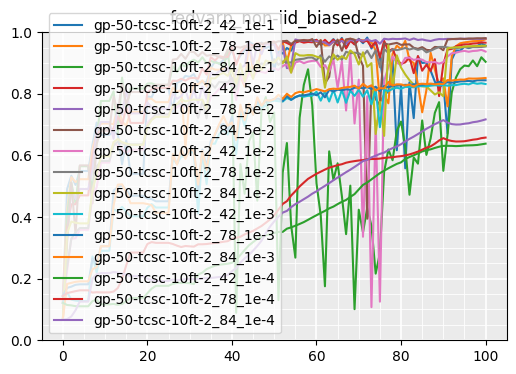

In [4]:
config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist", seeds=["42","78","84"],
                          algorithms=["fedvarp"], events=["global"],
                          lr_list=["1e-1", "5e-2","1e-2", "1e-3", "1e-4"], alphas=["0.1"], n_clients_list=["7"],
                          availabilities=["gp-50-tcsc-10ft-2"],
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

results_df = load_experiment_results(config)
plot_availability_comparison(config, results_df, "test_accuracy", folder=main_folder+'/comp-av-mat')

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  6.07it/s]


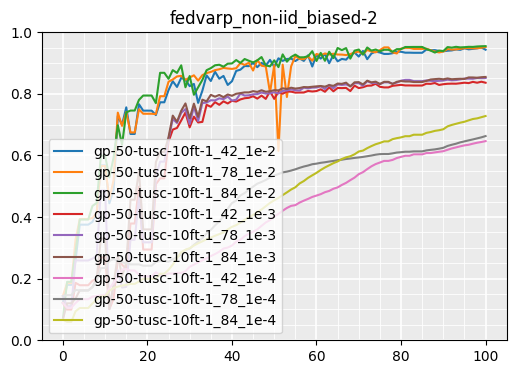

In [17]:
av_mat = 'gp-50-tusc-10ft-1'
p = Path(f"figures/lr_exp/{av_mat}/comp-av-mat/")
p.mkdir(parents=True, exist_ok=True)
config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist", seeds=["42","78","84"],
                          algorithms=["fedvarp"], events=["global"],
                          lr_list=["1e-2", "1e-3", "1e-4"], alphas=["0.1"], n_clients_list=["7"],
                          availabilities=[av_mat],
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

results_df = load_experiment_results(config)
plot_availability_comparison(config, results_df, "test_accuracy", folder=f'lr_exp/{av_mat}/comp-av-mat')

In [19]:
def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test) 


                                        if os.path.exists(event_dir):
                                            # print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, "availability": av,
                                                "alpha": a, "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "test_loss": "Test/Loss",
                                                "train_accuracy": "Train/Metric",
                                                "train_loss": "Train/Loss",
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

In [20]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist",
    seeds=["42", "78", "84"],
    algorithms=["fedavg", "fedvarp"],
    events=["global"],
    lr_list=["1e-1", "5e-2", "1e-2", "1e-3", "1e-4"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=list(
        "gaussian-corr-ft-35 gaussian-corr-ft-50 gaussian-uncorr-ft-35 gaussian-uncorr-ft-50 gp-35-tcsc-10ft-2 gp-35-tusc-10ft-2 gp-50-tcsc-10ft-2 gp-50-tusc-10ft-2 gp-20304050607080-tcsu-10ft gp-20304050607080-tusu-10ft gp-25255050507575-tcsu-10ft gp-25255050507575-tusu-10ft".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

In [32]:
tmp = results_df.groupby(['algorithm', 'availability','lr']).test_accuracy.apply(np.vstack).to_frame().reset_index()

In [57]:
tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))

# Plotting for each algo x av_mat the test accuracies across learning rate

In [103]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# Define the function for plotting based on selected algorithm and availability
def plot_accuracies(algorithm, availability):
    # Filter data based on the selected algorithm and availability
    filtered_data = tmp[(tmp['algorithm'] == algorithm) & (tmp['availability'] == availability)]
    
    # Create a single figure
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(f"{algorithm} - {availability}", fontsize=16)

    # Enable grid
    ax.grid(True)
    
    # Iterate over learning rates, all on the same plot
    for lr in ["1e-1", "5e-2", "1e-2", "1e-3", "1e-4"]:
        # Select the corresponding data for the current learning rate
        data_lr = filtered_data[filtered_data["lr"] == lr]
        
        # Check if there is data for this learning rate
        if data_lr.empty:
            continue

        mean_acc = data_lr['mean_test_acc'].values[0]
        min_acc = data_lr['min_test_acc'].values[0]
        max_acc = data_lr['max_test_acc'].values[0]
        mean_var = data_lr['var_test_acc'].values[0].mean()

        # Plot on the single plot
        ax.plot(range(len(mean_acc)), mean_acc, label=f'LR {float(lr)} - Mean Var: {mean_var:.4f}')
        ax.fill_between(range(len(mean_acc)), min_acc, max_acc, alpha=0.2)

    ax.legend()
    plt.show()

# Get unique values for algorithm and availability for the dropdowns
algorithms = tmp['algorithm'].unique()
availabilities = tmp['availability'].unique()

# Create interactive widgets
algorithm_widget = widgets.Dropdown(options=algorithms, description='Algorithm:')
availability_widget = widgets.Dropdown(options=availabilities, description='Availability:')

# Use `interact` to create the interactive plot
interact(plot_accuracies, algorithm=algorithm_widget, availability=availability_widget)


interactive(children=(Dropdown(description='Algorithm:', options=('fedavg', 'fedvarp'), value='fedavg'), Dropd…

<function __main__.plot_accuracies(algorithm, availability)>

In [59]:
res_ = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()]

# Comparing the best mean curves for algo x avail_mat combination

In [106]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# Helper function to plot data for a specific algorithm
def plot_algorithm_data(ax, data, algorithm_name):
    
    mean_acc = data['mean_test_acc'].values[0]
    min_acc = data['min_test_acc'].values[0]
    max_acc = data['max_test_acc'].values[0]
    mean_var = data['var_test_acc'].values[0].mean()
    lr = data['lr'].values[0]

    # Plot mean accuracy and range with labels
    ax.plot(range(len(mean_acc)), mean_acc, label=f'{algorithm_name} LR {lr} - Var: {mean_var:.4f}')
    ax.fill_between(range(len(mean_acc)), min_acc, max_acc, alpha=0.2)

# Main plotting function based on selected availability
def plot_accuracies(availability):
    filtered_data = res_[res_['availability'] == availability]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(f"{availability}", fontsize=16)
    ax.grid(True)

    # Plot data for each algorithm
    plot_algorithm_data(ax, filtered_data[filtered_data["algorithm"] == "fedavg"], "FedAvg")
    plot_algorithm_data(ax, filtered_data[filtered_data["algorithm"] == "fedvarp"], "FedVarp")
    
    ax.legend()
    plt.show()

# Get unique values for availability for the dropdown widget
availabilities = tmp['availability'].unique()

# Create interactive widget for availability selection
availability_widget = widgets.Dropdown(options=availabilities, description='Availability:')

# Use `interact` to enable interactive plotting
interact(plot_accuracies, availability=availability_widget)


interactive(children=(Dropdown(description='Availability:', options=('gaussian-corr-ft-35', 'gaussian-corr-ft-…

<function __main__.plot_accuracies(availability)>

In [109]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# Define the function for plotting based on selected algorithm and availability
av_group = {
    "corr": [
        "gaussian-corr-ft-35",
        "gaussian-corr-ft-50",
        "gp-20304050607080-tcsu-10ft",
        "gp-25255050507575-tcsu-10ft",
        "gp-35-tcsc-10ft-2",
        "gp-50-tcsc-10ft-2",
    ],
    "uncorr": [
        "gaussian-uncorr-ft-35",
        "gaussian-uncorr-ft-50",
        "gp-20304050607080-tusu-10ft",
        "gp-25255050507575-tusu-10ft",
        "gp-35-tusc-10ft-2",
        "gp-50-tusc-10ft-2",
    ],
}


def plot_accuracies(algorithm, corr_type):
    # Filter data based on the selected algorithm and availability
    filtered_data = res_[(tmp["algorithm"] == algorithm)]

    # Create a single figure
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(f"{algorithm}", fontsize=16)

    # Enable grid
    ax.grid(True)

    # Iterate over learning rates, all on the same plot
    for av_mat in av_group[corr_type]:
        # Select the corresponding data for the current learning rate
        data_av_mat = filtered_data[filtered_data["availability"] == av_mat]

        # Check if there is data for this learning rate
        if data_av_mat.empty:
            continue

        mean_acc = data_av_mat["mean_test_acc"].values[0]
        min_acc = data_av_mat["min_test_acc"].values[0]
        max_acc = data_av_mat["max_test_acc"].values[0]
        mean_var = data_av_mat["var_test_acc"].values[0].mean()

        # Plot on the single plot
        ax.plot(
            range(len(mean_acc)),
            mean_acc,
            label=f"{av_mat} LR {float(data_av_mat['lr'].values[0])} - Mean Var: {mean_var:.4f}",
        )
        ax.fill_between(range(len(mean_acc)), min_acc, max_acc, alpha=0.2)

    ax.legend()
    plt.show()


# Get unique values for algorithm and availability for the dropdowns
algorithms = tmp["algorithm"].unique()
corr_types = ['corr', 'uncorr']

# Create interactive widgets
algorithm_widget = widgets.Dropdown(options=algorithms, description="Algorithm:")
corr_types_widget = widgets.Dropdown(
    options=corr_types, description="corr_types:"
)

# Use `interact` to create the interactive plot
interact(plot_accuracies, algorithm=algorithm_widget, corr_type=corr_types_widget)

interactive(children=(Dropdown(description='Algorithm:', options=('fedavg', 'fedvarp'), value='fedavg'), Dropd…

<function __main__.plot_accuracies(algorithm, corr_type)>

In [63]:
from matplotlib.widgets import CheckButtons

Text(0.5, 1.0, 'FedAvg')

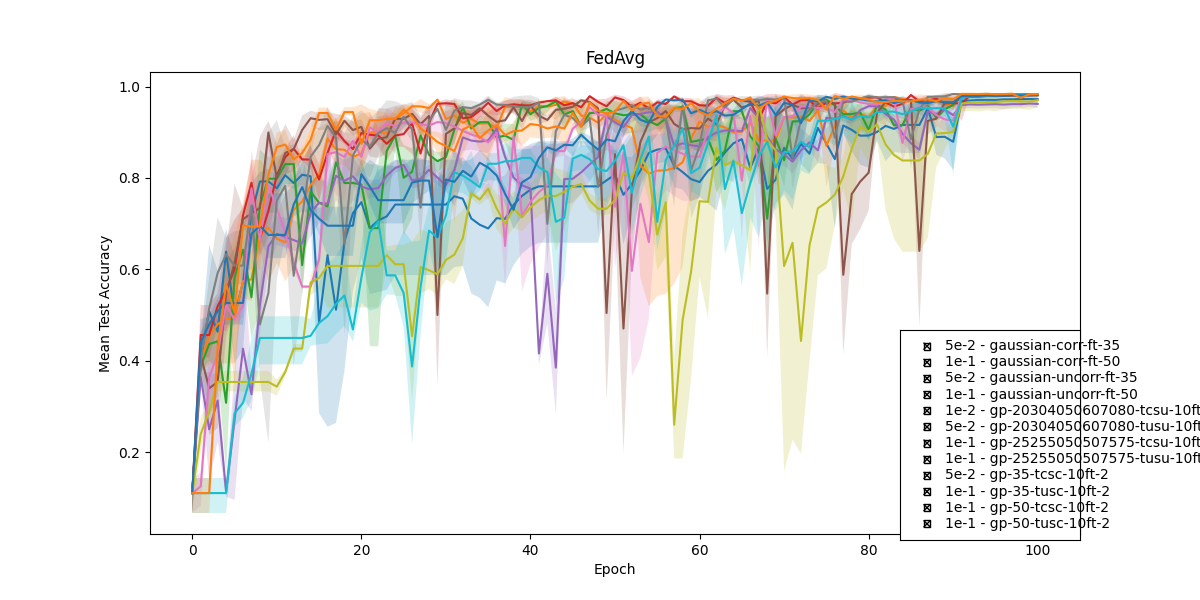

In [74]:
# Plotting mean accuracy with min-max range
fig, ax = plt.subplots(figsize=(12, 6))
lines = []
labels = []

for _, row in res_.loc[res_['algorithm'] == 'fedavg'].iterrows():
    mean_acc = row['mean_test_acc']
    min_acc = row['min_test_acc']
    max_acc = row['max_test_acc']
    label = f"{row['lr']} - {row['availability']}"
    
    # Plot mean line and shaded area
    line, = ax.plot(range(len(mean_acc)), mean_acc, label=label)
    shade = ax.fill_between(range(len(mean_acc)), min_acc, max_acc, alpha=0.2)
    
    lines.append((line, shade))  # Store line and shade for visibility toggling
    labels.append(label)
    
# Add CheckButtons for each line
rax = plt.axes([0.75, 0.1, 0.15, 0.35])  # Position of the CheckButtons
check = CheckButtons(rax, labels, [True] * len(labels))

# Define a function to toggle visibility
def toggle_visibility(label):
    index = labels.index(label)
    line, shade = lines[index]
    visible = not line.get_visible()
    line.set_visible(visible)
    shade.set_visible(visible)
    plt.draw()

# Connect the CheckButtons to the toggle function
check.on_clicked(toggle_visibility)

# Set plot labels and title
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Test Accuracy")
ax.set_title("FedAvg")


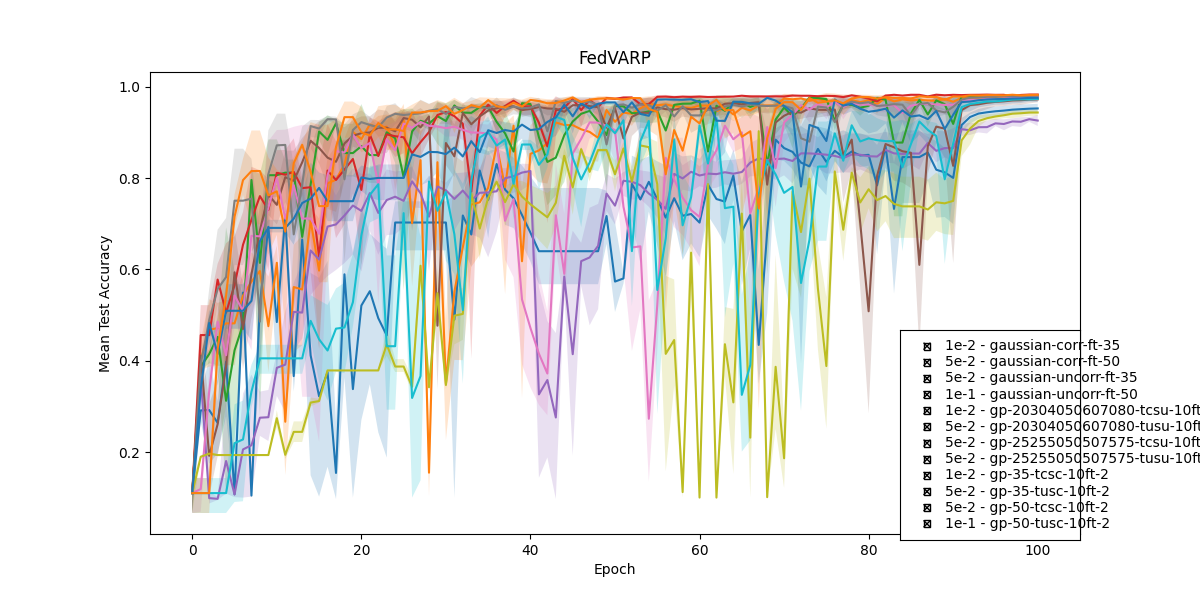

In [73]:
# Plotting mean accuracy with min-max range
fig, ax = plt.subplots(figsize=(12, 6))
lines = []
labels = []

for _, row in res_.loc[res_['algorithm'] == 'fedvarp'].iterrows():
    mean_acc = row['mean_test_acc']
    min_acc = row['min_test_acc']
    max_acc = row['max_test_acc']
    label = f"{row['lr']} - {row['availability']}"
    
    # Plot mean line and shaded area
    line, = ax.plot(range(len(mean_acc)), mean_acc, label=label)
    shade = ax.fill_between(range(len(mean_acc)), min_acc, max_acc, alpha=0.2)
    
    lines.append((line, shade))  # Store line and shade for visibility toggling
    labels.append(label)
    
# Add CheckButtons for each line
rax = plt.axes([0.75, 0.1, 0.15, 0.35])  # Position of the CheckButtons
check = CheckButtons(rax, labels, [True] * len(labels))

# Define a function to toggle visibility
def toggle_visibility(label):
    index = labels.index(label)
    line, shade = lines[index]
    visible = not line.get_visible()
    line.set_visible(visible)
    shade.set_visible(visible)
    plt.draw()

# Connect the CheckButtons to the toggle function
check.on_clicked(toggle_visibility)

# Set plot labels and title
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Test Accuracy")
ax.set_title("FedVARP")

plt.show()

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  6.96it/s]


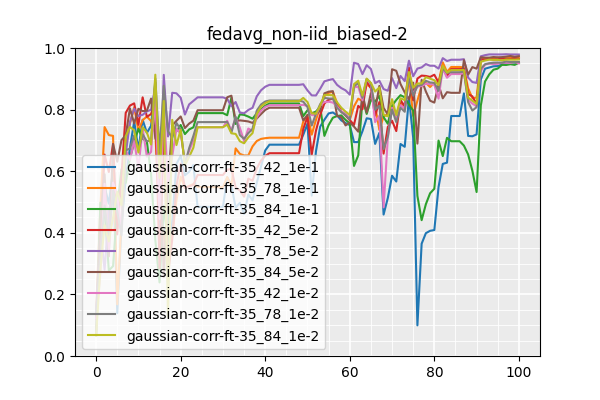

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  7.39it/s]


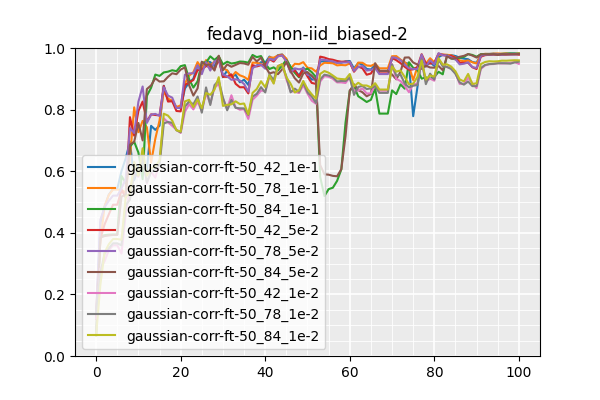

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  7.68it/s]


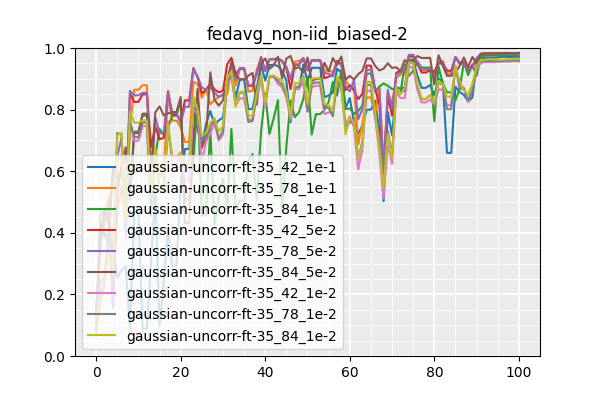

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  7.96it/s]


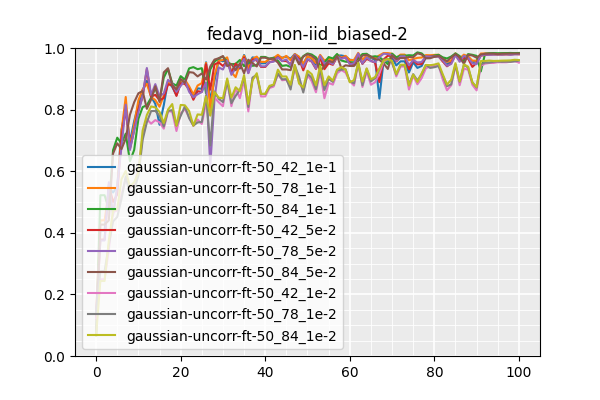

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  7.02it/s]


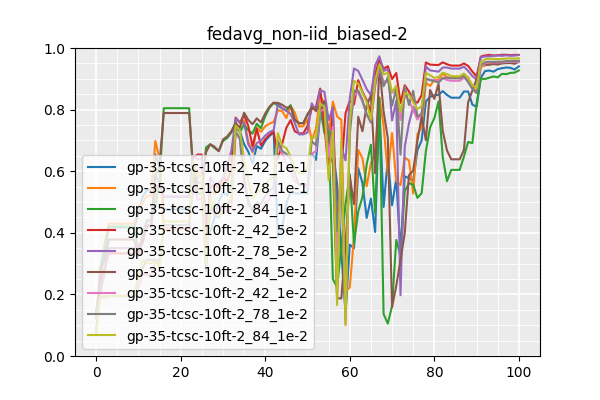

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  7.00it/s]


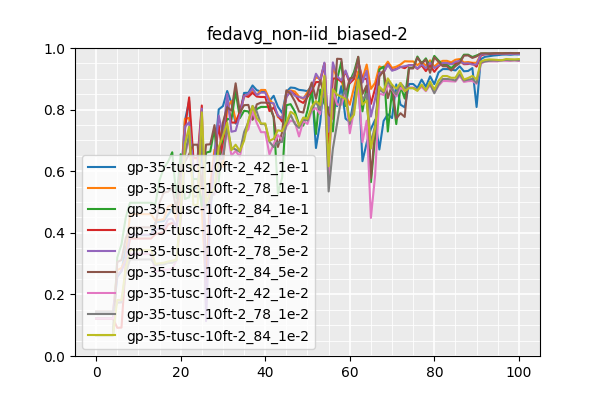

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  6.65it/s]


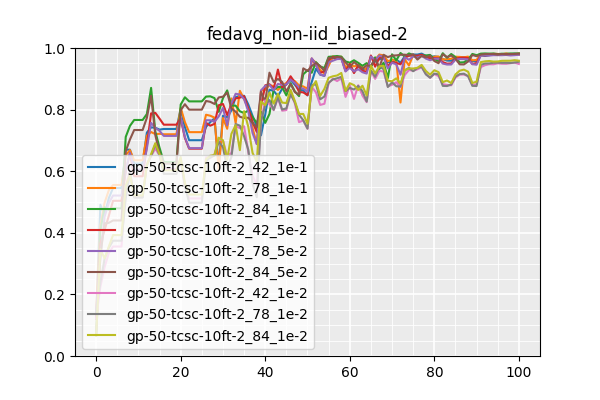

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  5.60it/s]


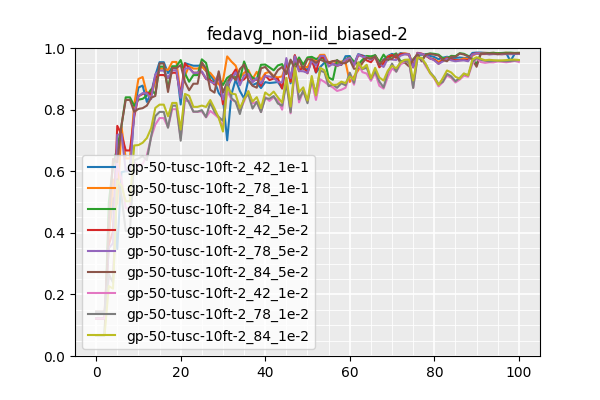

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  6.93it/s]


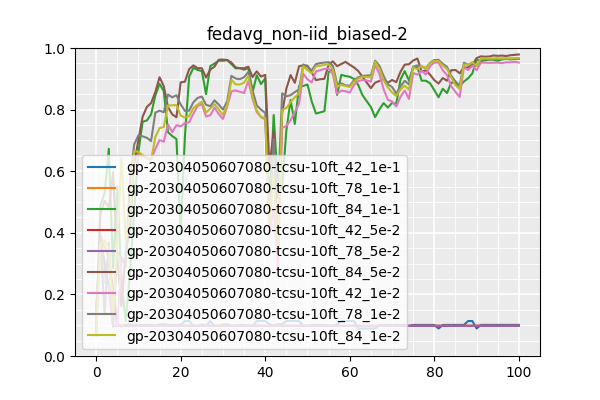

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  8.72it/s]


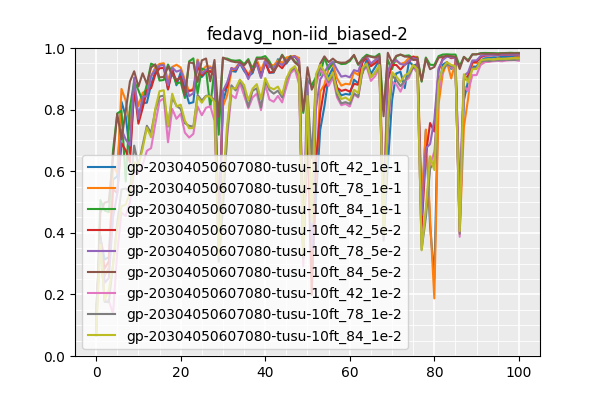

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  7.11it/s]


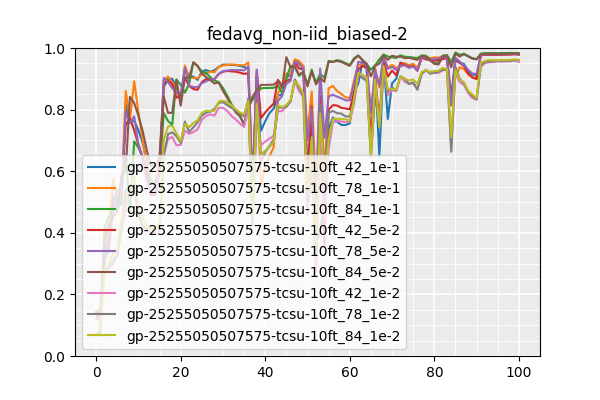

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  6.28it/s]


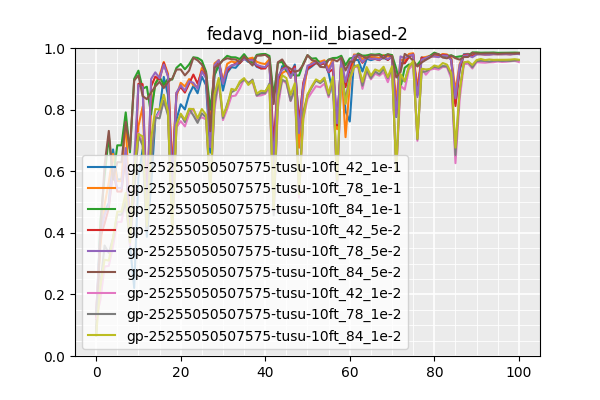

In [16]:
for av_mat in list("gaussian-corr-ft-35 gaussian-corr-ft-50 gaussian-uncorr-ft-35 gaussian-uncorr-ft-50 gp-35-tcsc-10ft-2 gp-35-tusc-10ft-2 gp-50-tcsc-10ft-2 gp-50-tusc-10ft-2 gp-20304050607080-tcsu-10ft gp-20304050607080-tusu-10ft gp-25255050507575-tcsu-10ft gp-25255050507575-tusu-10ft".split(" ")):
    p = Path(f"figures/lr_exp/{av_mat}/comp-av-mat/")
    p.mkdir(parents=True, exist_ok=True)
    config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist", seeds=["42","78","84"],
                            algorithms=["fedavg"], events=["global"],
                            lr_list=["1e-1", "5e-2", "1e-2"], alphas=["0.1"], n_clients_list=["7"],
                            availabilities=[av_mat],
                            n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

    results_df = load_experiment_results(config)
    plot_availability_comparison(config, results_df, "test_accuracy", folder=f'lr_exp/{av_mat}/comp-av-mat')

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  6.43it/s]


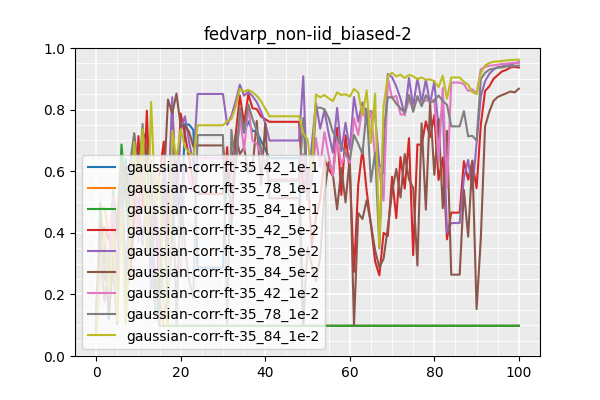

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  7.20it/s]


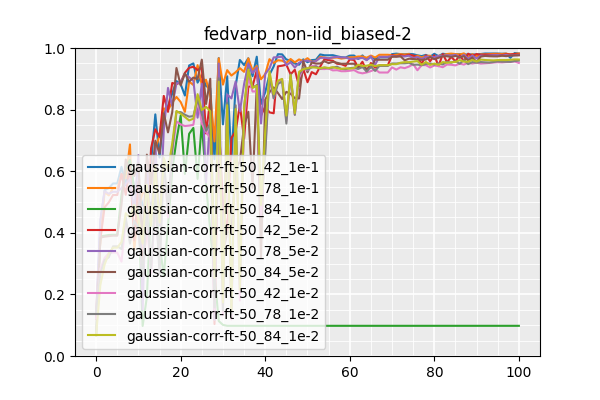

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  7.34it/s]


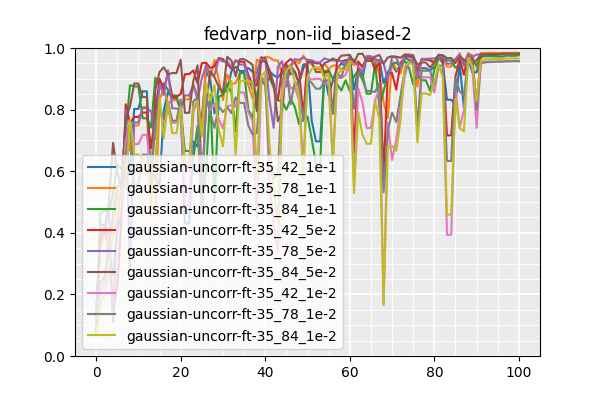

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  7.33it/s]


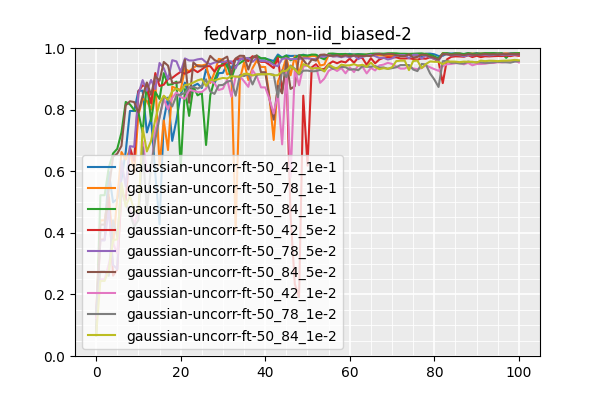

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  7.77it/s]


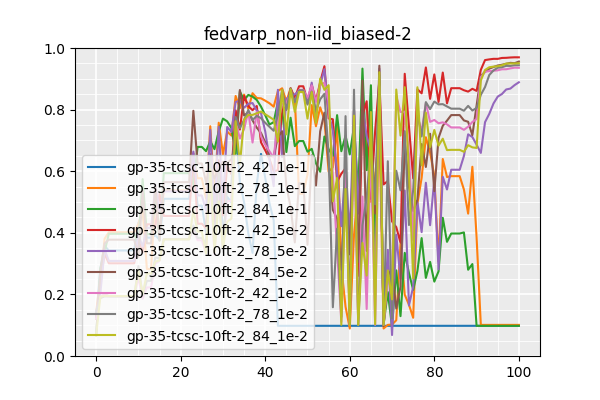

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  4.65it/s]


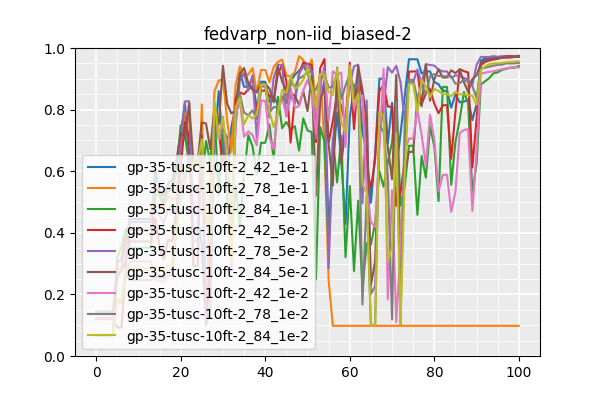

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  5.77it/s]


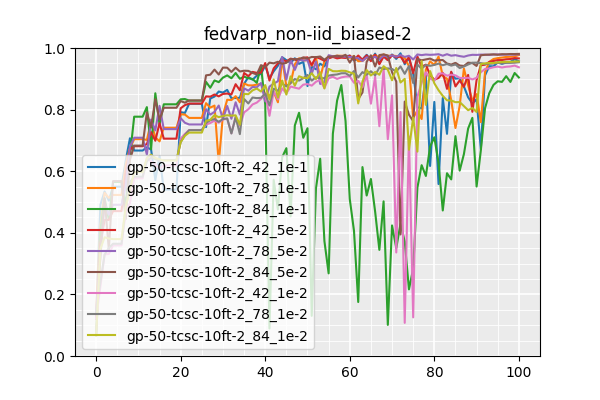

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  6.37it/s]


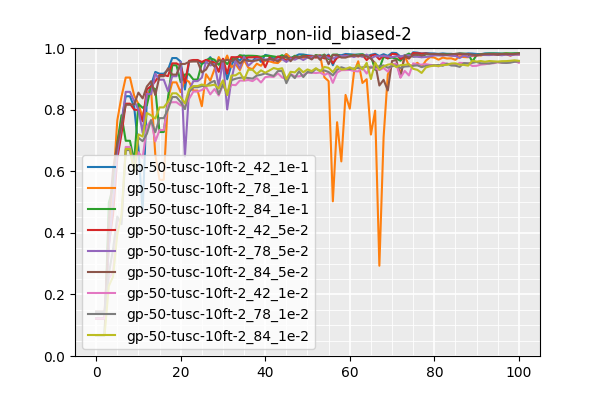

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  6.46it/s]
/run/netsop/u/home-sam/home/draviarp/Documents/FedStale/plots/plots_utils/plot_availability_comparison.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(6, 4))


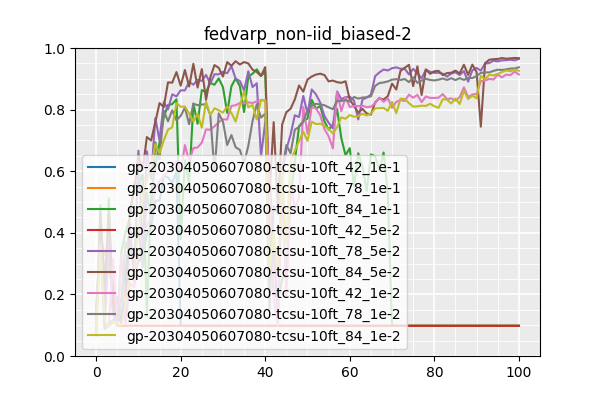

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  5.38it/s]


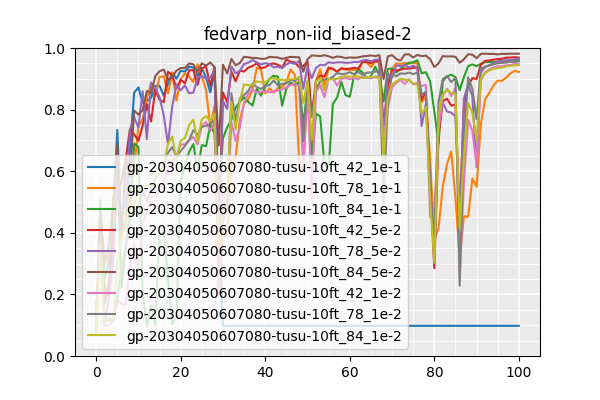

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  6.76it/s]


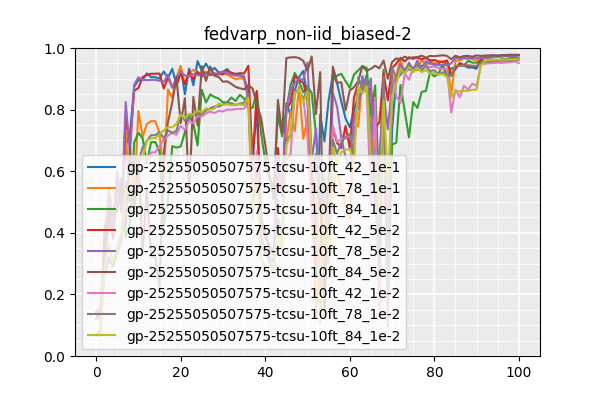

Processing experiments: 100%|██████████| 3/3 [00:00<00:00,  7.25it/s]


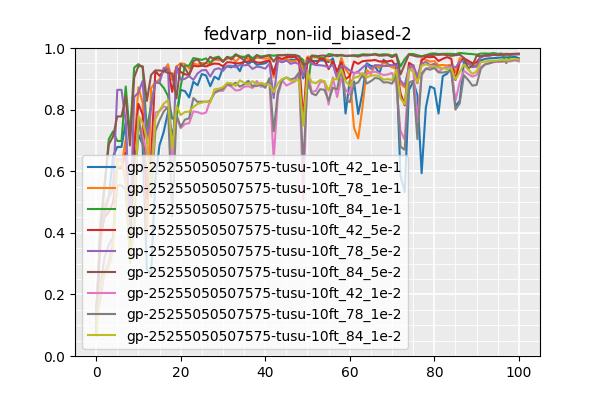

In [17]:
for av_mat in list("gaussian-corr-ft-35 gaussian-corr-ft-50 gaussian-uncorr-ft-35 gaussian-uncorr-ft-50 gp-35-tcsc-10ft-2 gp-35-tusc-10ft-2 gp-50-tcsc-10ft-2 gp-50-tusc-10ft-2 gp-20304050607080-tcsu-10ft gp-20304050607080-tusu-10ft gp-25255050507575-tcsu-10ft gp-25255050507575-tusu-10ft".split(" ")):
    p = Path(f"figures/lr_exp/{av_mat}/comp-av-mat/")
    p.mkdir(parents=True, exist_ok=True)
    config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist", seeds=["42","78","84"],
                            algorithms=["fedvarp"], events=["global"],
                            lr_list=["1e-1", "5e-2", "1e-2"], alphas=["0.1"], n_clients_list=["7"],
                            availabilities=[av_mat],
                            n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

    results_df = load_experiment_results(config)
    plot_availability_comparison(config, results_df, "test_accuracy", folder=f'lr_exp/{av_mat}/comp-av-mat')

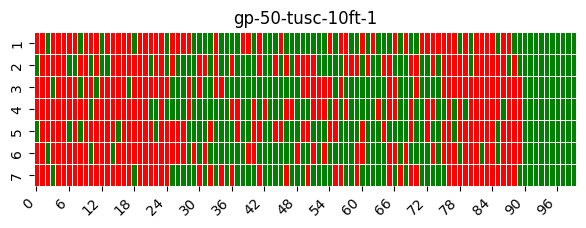

In [33]:
main_folder = 'lr_exp/gp-50-tusc-10ft-1'
p = Path("figures/lr_exp/gp-50-tusc-10ft-1")
p.mkdir(parents=True, exist_ok=True)
for av_mat_name in ["gp-50-tusc-10ft-1"]:
    plot_av_mat(av_mat_name, main_folder)